# Task 4 — Advanced ML: Train, Optimize, and Deploy a Model

This notebook trains and hyperparameter-tunes a student-performance regression model. The saved artifacts are consumed by the FastAPI service in `../app/main.py`, which is connected to a small HTML/JS dashboard (`../app/static/index.html`). See `../README.md` for the full deployment pipeline documentation.

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
DATA_DIR = Path("../data"); IMG_DIR = Path("../images"); OUT_DIR = Path("../outputs")
for d in (DATA_DIR, IMG_DIR, OUT_DIR): d.mkdir(exist_ok=True)


## 2. Load data

In [3]:
df = pd.read_csv(DATA_DIR / "student_performance.csv")
df.head()


,study_hours,attendance_percent,previous_scores,sleep_hours,extracurricular,parental_education,internet_access,final_score
0,4.57,100.0,66.1,8.43,No,High School,Yes,73.5
1,7.22,100.0,60.7,7.20,Yes,High School,Yes,76.6
2,6.95,93.4,59.0,5.55,No,Bachelors,Yes,78.3
3,3.48,80.4,74.0,8.10,Yes,Masters,Yes,65.8
4,3.90,89.9,74.4,6.57,Yes,Masters,No,74.0


## 3. Preprocess

In [4]:
label_encoders = {}
df_enc = df.copy()
for col in ["extracurricular","parental_education","internet_access"]:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_).tolist()))

feature_cols = ["study_hours","attendance_percent","previous_scores","sleep_hours",
                "extracurricular","parental_education","internet_access"]
X = df_enc[feature_cols]; y = df_enc["final_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Baseline model

In [5]:
baseline = LinearRegression().fit(X_train_scaled, y_train)
baseline_preds = baseline.predict(X_test_scaled)
baseline_metrics = {
    "MAE": mean_absolute_error(y_test, baseline_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, baseline_preds)),
    "R2": r2_score(y_test, baseline_preds),
}
baseline_metrics


{'MAE': 4.1857574400197635,
 'RMSE': np.float64(5.294954411213515),
 'R2': 0.6576784912730362}

## 5. Hyperparameter optimization (GridSearchCV on Random Forest)

In [6]:
param_grid = {"n_estimators":[100,200,300], "max_depth":[4,6,8,10], "min_samples_leaf":[1,2,4]}
grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train_scaled, y_train)
best_model = grid.best_estimator_
best_preds = best_model.predict(X_test_scaled)
best_metrics = {
    "MAE": mean_absolute_error(y_test, best_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, best_preds)),
    "R2": r2_score(y_test, best_preds),
}
print(grid.best_params_)
best_metrics


{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}


{'MAE': 4.581075110137596,
 'RMSE': np.float64(5.800235339791998),
 'R2': 0.5892278726388642}

## 6. Pick the model to deploy
We deploy whichever model generalizes better on the held-out test set.

In [7]:
final_name, final_model, final_metrics = (
    ("RandomForest_Tuned", best_model, best_metrics) if best_metrics["R2"] >= baseline_metrics["R2"]
    else ("LinearRegression", baseline, baseline_metrics)
)
print("Deploying:", final_name, final_metrics)


Deploying: LinearRegression {'MAE': 4.1857574400197635, 'RMSE': np.float64(5.294954411213515), 'R2': 0.6576784912730362}


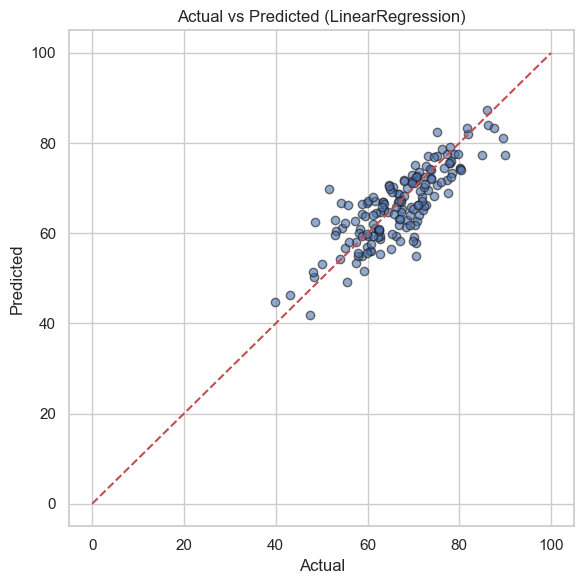

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, final_model.predict(X_test_scaled), alpha=0.6, edgecolor="k")
plt.plot([0,100],[0,100],"r--")
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title(f"Actual vs Predicted ({final_name})")
plt.tight_layout(); plt.savefig(IMG_DIR/"actual_vs_predicted.png", dpi=120); plt.show()


## 7. Save artifacts for the FastAPI service

In [9]:
joblib.dump(final_model, OUT_DIR/"model.joblib")
joblib.dump(scaler, OUT_DIR/"scaler.joblib")
with open(OUT_DIR/"label_encoders.json","w") as f: json.dump(label_encoders, f, indent=2)
with open(OUT_DIR/"feature_columns.json","w") as f: json.dump(feature_cols, f, indent=2)

APP_MODEL_DIR = Path("../app/model_artifacts"); APP_MODEL_DIR.mkdir(exist_ok=True, parents=True)
joblib.dump(final_model, APP_MODEL_DIR/"model.joblib")
joblib.dump(scaler, APP_MODEL_DIR/"scaler.joblib")
with open(APP_MODEL_DIR/"label_encoders.json","w") as f: json.dump(label_encoders, f, indent=2)
with open(APP_MODEL_DIR/"feature_columns.json","w") as f: json.dump(feature_cols, f, indent=2)
print("Artifacts saved. Start the API with: uvicorn app.main:app --reload")


Artifacts saved. Start the API with: uvicorn app.main:app --reload


## Conclusion
The model and preprocessing objects are serialized to `app/model_artifacts/`, which `app/main.py` (a FastAPI service with Pydantic input validation) loads at startup. A bundled static dashboard (`app/static/index.html`) provides a simple UI on top of the `/predict` endpoint. See the project README for how to run and test the full deployment.